<a href="https://colab.research.google.com/github/OguzhanB16/Deep-Learning/blob/main/Animal_faces.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/animal-faces")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animal-faces' dataset.
Path to dataset files: /kaggle/input/animal-faces


In [15]:
import torch
import torch.optim as optim
import torch.nn as nn
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd
import PIL.Image as Image
import os
import numpy as np
from torchsummary import summary

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [16]:
image_path = []
labels = []

for i in os.listdir("/kaggle/input/animal-faces/afhq"):
  for label in os.listdir(f"/kaggle/input/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/kaggle/input/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/kaggle/input/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame({"image_path": image_path, "labels": labels})
data_df.head()

,image_path,labels
0,/kaggle/input/animal-faces/afhq/val/dog/flickr...,dog
1,/kaggle/input/animal-faces/afhq/val/dog/pixaba...,dog
2,/kaggle/input/animal-faces/afhq/val/dog/flickr...,dog
3,/kaggle/input/animal-faces/afhq/val/dog/flickr...,dog
4,/kaggle/input/animal-faces/afhq/val/dog/pixaba...,dog


In [17]:
print(data_df['labels'].unique()) # 3 class cat, dog or wild
print(len(data_df)) # Total image

['dog' 'wild' 'cat']
16130


In [18]:
# Data split (%70 train, %15 val, %15 test)
train = data_df.sample(frac=0.7, random_state=42)
kalan_veri = data_df.drop(train.index)
val = kalan_veri.sample(frac=0.5, random_state=42)
test = kalan_veri.drop(val.index)

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 11291, Val: 2420, Test: 2419


In [19]:
# Setting label_encoder and transforms
label_encoder = LabelEncoder()
label_encoder.fit(data_df['labels'])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [20]:
# Creating our custom dataset class
class CustomDataset(Dataset):
  def __init__(self, df, label_encoder, transform=None):
    self.df = df
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(df['labels']), dtype=torch.long)

  def __getitem__(self, index):
    image_path = self.df.iloc[index]['image_path']
    label = self.labels[index]

    image = Image.open(image_path).convert("RGB")

    if self.transform:
      image = self.transform(image)

    return image, label

  def __len__(self):
    return len(self.df)

In [21]:
train_dataset = CustomDataset(train, label_encoder, transform)
val_dataset = CustomDataset(val, label_encoder, transform)
test_dataset = CustomDataset(test, label_encoder, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

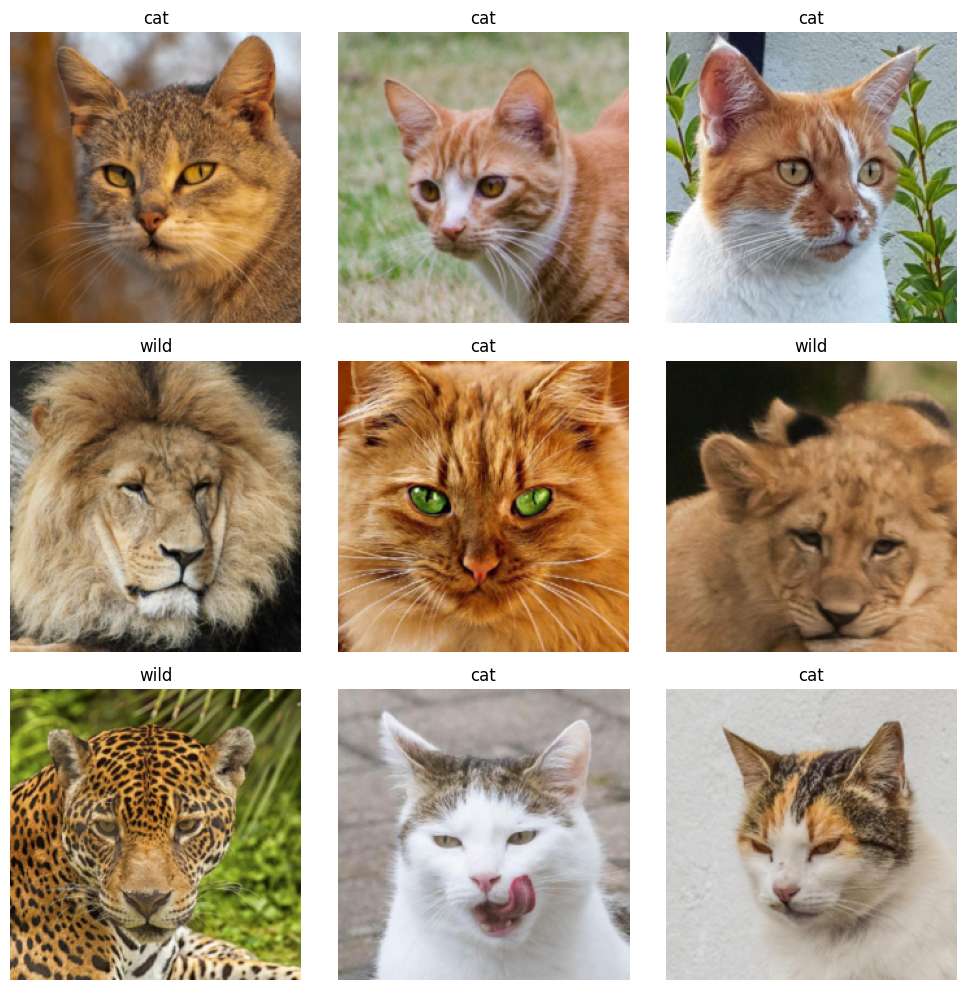

In [22]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Inverse transform the labels to get original class names
original_labels = label_encoder.inverse_transform(labels.cpu().numpy())

fig = plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Unnormalize and permute dimensions for displaying the image
    img = images[i].numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(original_labels[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [23]:
# Creating resnet-18 class
class BasicBlock(nn.Module):
  def __init__(self, in_channels, out_channels, stride=1):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.shortcut = nn.Sequential()
    if stride != 1 or in_channels != out_channels:
      self.shortcut = nn.Sequential(
          nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
          nn.BatchNorm2d(out_channels)
      )

  def forward(self, x):
    residual = x
    out = self.conv1(x)
    out = self.bn1(out)
    out = nn.ReLU()(out)
    out = self.conv2(out)
    out = self.bn2(out)

    residual = self.shortcut(x)
    out += residual
    out = nn.ReLU()(out)
    return out

class ResNet18(nn.Module):
  def __init__(self):
    super().__init__()
    self.in_channels = 64
    self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
    self.bn1 = nn.BatchNorm2d(64)
    self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
    self.layer1 = self.make_layer(BasicBlock, 64, 2, stride=1)
    self.layer2 = self.make_layer(BasicBlock, 128, 2, stride=2)
    self.layer3 = self.make_layer(BasicBlock, 256, 2, stride=2)
    self.layer4 = self.make_layer(BasicBlock, 512, 2, stride=2)
    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(512, 3)

  def make_layer(self, block, out_channels, num_blocks, stride):
    strides = [stride] + [1] * (num_blocks - 1)
    layers = []
    for stride in strides:
      layers.append(block(self.in_channels, out_channels, stride))
      self.in_channels = out_channels
    return nn.Sequential(*layers)

  def forward(self, x):
    out = self.conv1(x)
    out = self.bn1(out)
    out = nn.ReLU()(out)
    out = self.maxpool(out)
    out = self.layer1(out)
    out = self.layer2(out)
    out = self.layer3(out)
    out = self.layer4(out)
    out = self.avgpool(out)
    out = out.view(out.size(0), -1)
    out = self.fc(out)
    return out


In [24]:
model = ResNet18().to(device)
summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
         MaxPool2d-3           [-1, 64, 56, 56]               0
            Conv2d-4           [-1, 64, 56, 56]          36,864
       BatchNorm2d-5           [-1, 64, 56, 56]             128
            Conv2d-6           [-1, 64, 56, 56]          36,864
       BatchNorm2d-7           [-1, 64, 56, 56]             128
        BasicBlock-8           [-1, 64, 56, 56]               0
            Conv2d-9           [-1, 64, 56, 56]          36,864
      BatchNorm2d-10           [-1, 64, 56, 56]             128
           Conv2d-11           [-1, 64, 56, 56]          36,864
      BatchNorm2d-12           [-1, 64, 56, 56]             128
       BasicBlock-13           [-1, 64, 56, 56]               0
           Conv2d-14          [-1, 128,

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [26]:
epochs = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    # Training loop

    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # Validation loop

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.inference_mode():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    print(f"Epoch: {epoch+1}/{epochs} | "
      f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
      f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

Epoch: 1/10 | Train Loss: 0.7666 | Train Acc: 0.6476 | Val Loss: 0.8723 | Val Acc: 0.6364
Epoch: 2/10 | Train Loss: 0.3106 | Train Acc: 0.8842 | Val Loss: 0.2494 | Val Acc: 0.9029
Epoch: 3/10 | Train Loss: 0.1837 | Train Acc: 0.9314 | Val Loss: 0.3096 | Val Acc: 0.8884
Epoch: 4/10 | Train Loss: 0.1312 | Train Acc: 0.9522 | Val Loss: 0.2825 | Val Acc: 0.8955
Epoch: 5/10 | Train Loss: 0.0909 | Train Acc: 0.9676 | Val Loss: 0.0992 | Val Acc: 0.9657
Epoch: 6/10 | Train Loss: 0.0817 | Train Acc: 0.9704 | Val Loss: 0.0693 | Val Acc: 0.9744
Epoch: 7/10 | Train Loss: 0.0636 | Train Acc: 0.9770 | Val Loss: 0.0702 | Val Acc: 0.9731
Epoch: 8/10 | Train Loss: 0.0501 | Train Acc: 0.9815 | Val Loss: 0.1187 | Val Acc: 0.9612
Epoch: 9/10 | Train Loss: 0.0375 | Train Acc: 0.9851 | Val Loss: 0.0881 | Val Acc: 0.9686
Epoch: 10/10 | Train Loss: 0.0354 | Train Acc: 0.9879 | Val Loss: 0.0816 | Val Acc: 0.9723


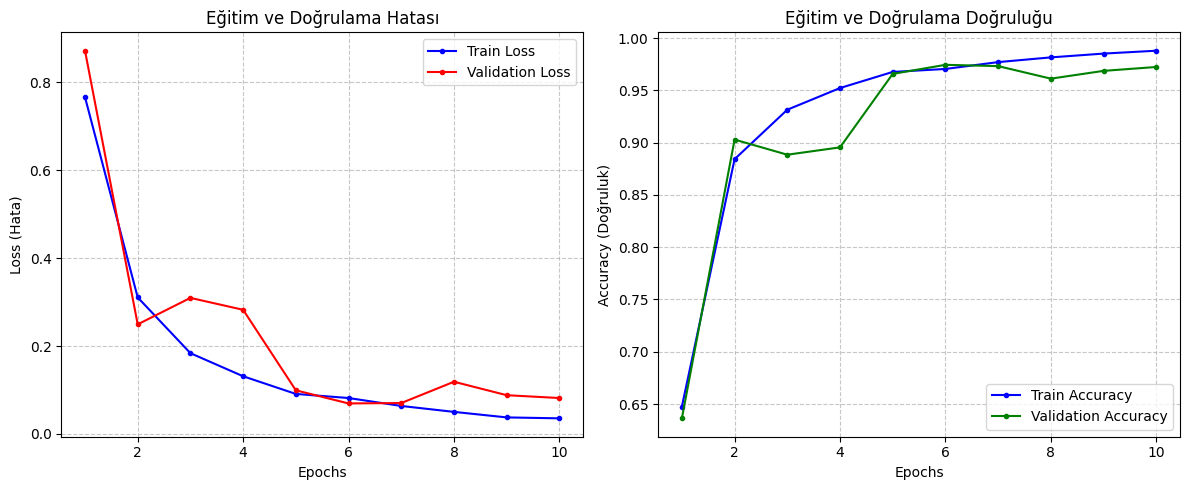

In [27]:
import matplotlib.pyplot as plt

# X ekseni için 1'den epoch sayısına kadar bir liste oluştur (Örn: 1, 2, 3... 100)
epochs_range = range(1, epochs + 1)

# Çizim alanının boyutunu ayarla (Genişlik: 12, Yükseklik: 5)
plt.figure(figsize=(12, 5))

# --- 1. Grafik: Hata (Loss) ---
plt.subplot(1, 2, 1) # 1 satır, 2 sütunlu grafiğin 1.si
plt.plot(epochs_range, train_losses, label='Train Loss', color='blue', marker='o', markersize=3)
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', marker='o', markersize=3)
plt.xlabel('Epochs')
plt.ylabel('Loss (Hata)')
plt.title('Eğitim ve Doğrulama Hatası')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# --- 2. Grafik: Doğruluk (Accuracy) ---
plt.subplot(1, 2, 2) # 1 satır, 2 sütunlu grafiğin 2.si
plt.plot(epochs_range, train_accuracies, label='Train Accuracy', color='blue', marker='o', markersize=3)
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy', color='green', marker='o', markersize=3)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (Doğruluk)')
plt.title('Eğitim ve Doğrulama Doğruluğu')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Grafikleri ekranda düzgün yerleştir ve göster
plt.tight_layout()
plt.show()